In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import torch
import torch.nn as nn

# load data once — all models will use this
df_deaths = pd.read_csv('../data/Deaths_1x1.txt', skiprows=2, sep=r'\s+')
df_deaths['Age'] = df_deaths['Age'].replace('110+', 110).astype(int)
df_exposure = pd.read_csv('../data/Exposures_1x1.txt', skiprows=2, sep=r'\s+')
df_exposure['Age'] = df_exposure['Age'].replace('110+', 110).astype(int)

df = df_deaths.merge(df_exposure, on=['Year', 'Age'], suffixes=('_deaths', '_exp'))
df['mx_total'] = df['Total_deaths'] / df['Total_exp']
df = df[(df['Age'] <= 100) & (df['mx_total'] > 0)].copy()
df['log_mx_total'] = np.log(df['mx_total'])
df['log_age'] = np.log1p(df['Age'])
df['age_squared'] = df['Age'] ** 2

# standard train/test split used across all models
train_mask = df['Year'] <= 2000
test_mask = df['Year'] > 2000

print(f"Train: {train_mask.sum()} rows, Test: {test_mask.sum()} rows")
print(f"Test years: {df[test_mask]['Year'].min()} to {df[test_mask]['Year'].max()}")

Train: 8080 rows, Test: 2121 rows
Test years: 2001 to 2021


In [3]:
# ── MODEL 1: LEE-CARTER ──────────────────────────────────────────────────────
matrix = df.pivot(index='Age', columns='Year', values='mx_total')
log_mx = np.log(matrix.values)
ages = matrix.index.values
years = matrix.columns.values

# fit on training data only
matrix_train = matrix[matrix.columns[matrix.columns <= 2000]]
log_mx_train = np.log(matrix_train.values)
years_train = matrix_train.columns.values

alpha_lc = log_mx_train.mean(axis=1)
centred = log_mx_train - alpha_lc[:, np.newaxis]
U, S, Vt = np.linalg.svd(centred)
beta_lc = U[:, 0] / U[:, 0].sum()
kappa_lc = Vt[0, :] * S[0] * U[:, 0].sum()

post1950 = years_train >= 1950
lr_lc = LinearRegression()
lr_lc.fit(years_train[post1950].reshape(-1, 1), kappa_lc[post1950])

test_years = years[years > 2000]
kappa_fore = lr_lc.predict(test_years.reshape(-1, 1))
pred_log_lc = alpha_lc[:, np.newaxis] + beta_lc[:, np.newaxis] * kappa_fore[np.newaxis, :]

# get actual test values
matrix_test = matrix[matrix.columns[matrix.columns > 2000]]
actual_log_test = np.log(matrix_test.values)

mae_lc = mean_absolute_error(actual_log_test.flatten(), pred_log_lc.flatten())
rmse_lc = np.sqrt(mean_squared_error(actual_log_test.flatten(), pred_log_lc.flatten()))
print(f"Lee-Carter  — MAE: {mae_lc:.4f}  RMSE: {rmse_lc:.4f}")

Lee-Carter  — MAE: 0.2367  RMSE: 0.2896


In [4]:
# ── MODEL 2: XGBOOST ─────────────────────────────────────────────────────────
features = ['Age', 'Year', 'log_age', 'age_squared']
X = df[features].values
y = df['log_mx_total'].values

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

model_xgb = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbosity=0
)
model_xgb.fit(X_train, y_train, verbose=False)
pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print(f"XGBoost     — MAE: {mae_xgb:.4f}  RMSE: {rmse_xgb:.4f}")

XGBoost     — MAE: 0.2671  RMSE: 0.3370


In [11]:
# ── MODEL 3: NEURAL NETWORK ──────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test_scaled)

from torch.utils.data import DataLoader, TensorDataset

class MortalityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x).squeeze()

model_nn = MortalityNet()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
criterion = nn.MSELoss()
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

for epoch in range(1000):
    model_nn.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        criterion(model_nn(X_batch), y_batch).backward()
        optimizer.step()

model_nn.eval()
with torch.no_grad():
    pred_nn = model_nn(X_test_t).numpy()

mae_nn = mean_absolute_error(y_test, pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, pred_nn))
print(f"Neural Net  — MAE: {mae_nn:.4f}  RMSE: {rmse_nn:.4f}")

Neural Net  — MAE: 0.1769  RMSE: 0.2679


In [12]:
# ── MODEL 4: CBD ─────────────────────────────────────────────────────────────
df_cbd = df[(df['Age'] >= 60) & (df['Age'] <= 89)].copy()
df_cbd = df_cbd[df_cbd['mx_total'] > 0].copy()
df_cbd['qx'] = df_cbd['mx_total'] / (1 + 0.5 * df_cbd['mx_total'])
df_cbd = df_cbd[df_cbd['qx'] < 1].copy()
df_cbd['logit_qx'] = np.log(df_cbd['qx'] / (1 - df_cbd['qx']))

x_bar = 74.5
df_cbd['age_centred'] = df_cbd['Age'] - x_bar

# fit kappas on training years only
cbd_train = df_cbd[df_cbd['Year'] <= 2000]
cbd_test = df_cbd[df_cbd['Year'] > 2000]

train_years_cbd = sorted(cbd_train['Year'].unique())
kappa1, kappa2 = [], []

for yr in train_years_cbd:
    yr_data = cbd_train[cbd_train['Year'] == yr]
    lr = LinearRegression()
    lr.fit(yr_data['age_centred'].values.reshape(-1, 1), yr_data['logit_qx'].values)
    kappa1.append(lr.intercept_)
    kappa2.append(lr.coef_[0])

kappa1 = np.array(kappa1)
kappa2 = np.array(kappa2)
train_years_cbd = np.array(train_years_cbd)

# forecast kappas forward
post1950 = train_years_cbd >= 1950
lr1 = LinearRegression()
lr1.fit(train_years_cbd[post1950].reshape(-1, 1), kappa1[post1950])
lr2 = LinearRegression()
lr2.fit(train_years_cbd[post1950].reshape(-1, 1), kappa2[post1950])

test_years_cbd = np.array(sorted(cbd_test['Year'].unique()))
kappa1_fore = lr1.predict(test_years_cbd.reshape(-1, 1))
kappa2_fore = lr2.predict(test_years_cbd.reshape(-1, 1))

# predict and evaluate on log mx scale
actual_list, predicted_list = [], []
for i, yr in enumerate(test_years_cbd):
    for age in range(60, 90):
        age_c = age - x_bar
        pred_logit = kappa1_fore[i] + kappa2_fore[i] * age_c
        pred_qx = np.exp(pred_logit) / (1 + np.exp(pred_logit))
        pred_mx = pred_qx / (1 - 0.5 * pred_qx)
        pred_log_mx = np.log(pred_mx)
        actual_row = df_cbd[(df_cbd['Year'] == yr) & (df_cbd['Age'] == age)]
        if len(actual_row) > 0:
            actual_list.append(np.log(actual_row['mx_total'].values[0]))
            predicted_list.append(pred_log_mx)

actual_cbd = np.array(actual_list)
pred_cbd = np.array(predicted_list)

mae_cbd = mean_absolute_error(actual_cbd, pred_cbd)
rmse_cbd = np.sqrt(mean_squared_error(actual_cbd, pred_cbd))
print(f"CBD         — MAE: {mae_cbd:.4f}  RMSE: {rmse_cbd:.4f}  (ages 60-89 only)")

CBD         — MAE: 0.1972  RMSE: 0.2193  (ages 60-89 only)


In [13]:
print("\n── FULL RESULTS TABLE ──────────────────────────────────────")
print(f"{'Model':<15} {'Test MAE':>10} {'Test RMSE':>10} {'Age Range':>12}")
print("-" * 50)
print(f"{'Lee-Carter':<15} {mae_lc:>10.4f} {rmse_lc:>10.4f} {'0-100':>12}")
print(f"{'XGBoost':<15} {mae_xgb:>10.4f} {rmse_xgb:>10.4f} {'0-100':>12}")
print(f"{'Neural Net':<15} {mae_nn:>10.4f} {rmse_nn:>10.4f} {'0-100':>12}")
print(f"{'CBD':<15} {mae_cbd:>10.4f} {rmse_cbd:>10.4f} {'60-89':>12}")


── FULL RESULTS TABLE ──────────────────────────────────────
Model             Test MAE  Test RMSE    Age Range
--------------------------------------------------
Lee-Carter          0.2367     0.2896        0-100
XGBoost             0.2671     0.3370        0-100
Neural Net          0.1769     0.2679        0-100
CBD                 0.1972     0.2193        60-89


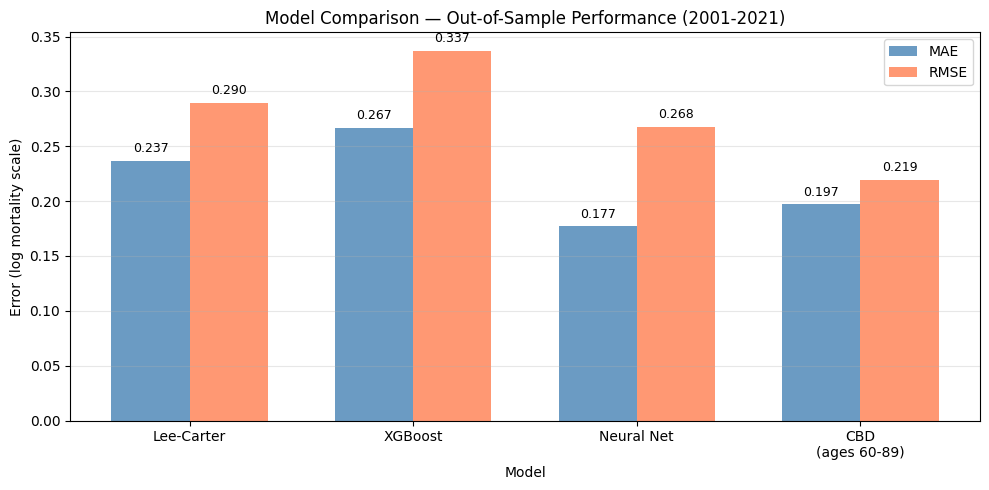

In [14]:
# ── VISUALISATION 1: SUMMARY BAR CHART ───────────────────────────────────────
models = ['Lee-Carter', 'XGBoost', 'Neural Net', 'CBD\n(ages 60-89)']
maes = [mae_lc, mae_xgb, mae_nn, mae_cbd]
rmses = [rmse_lc, rmse_xgb, rmse_nn, rmse_cbd]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, maes, width, label='MAE', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, rmses, width, label='RMSE', color='coral', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Error (log mortality scale)')
ax.set_title('Model Comparison — Out-of-Sample Performance (2001-2021)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

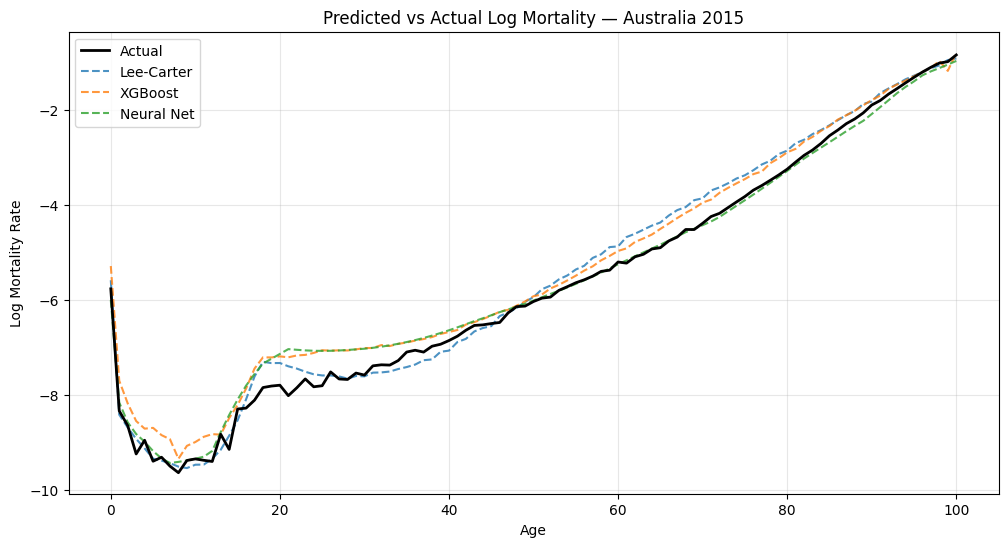

In [23]:
# ── VISUALISATION 2: PREDICTED VS ACTUAL FOR 2015 ────────────────────────────
yr = 2015
ages_plot = np.arange(0, 101)

# actual
actual_2015 = df[df['Year'] == yr].sort_values('Age')['log_mx_total'].values

# lee-carter prediction
yr_idx = np.where(test_years == yr)[0][0]
lc_2015 = alpha_lc + beta_lc * kappa_fore[yr_idx]

# xgboost prediction
X_2015 = np.column_stack([
    ages_plot,
    np.full(101, yr),
    np.log1p(ages_plot),
    ages_plot ** 2
])
xgb_2015 = model_xgb.predict(X_2015)

# neural net prediction
X_2015_scaled = scaler.transform(X_2015)
X_2015_t = torch.FloatTensor(X_2015_scaled)
model_nn.eval()
with torch.no_grad():
    nn_2015 = model_nn(X_2015_t).numpy()

# plot
plt.figure(figsize=(12, 6))
plt.plot(ages_plot, actual_2015, 'k-', linewidth=2, label='Actual', zorder=5)
plt.plot(ages_plot, lc_2015, '--', label='Lee-Carter', alpha=0.8)
plt.plot(ages_plot, xgb_2015, '--', label='XGBoost', alpha=0.8)
plt.plot(ages_plot, nn_2015, '--', label='Neural Net', alpha=0.8)

plt.xlabel('Age')
plt.ylabel('Log Mortality Rate')
plt.title(f'Predicted vs Actual Log Mortality — Australia {yr}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

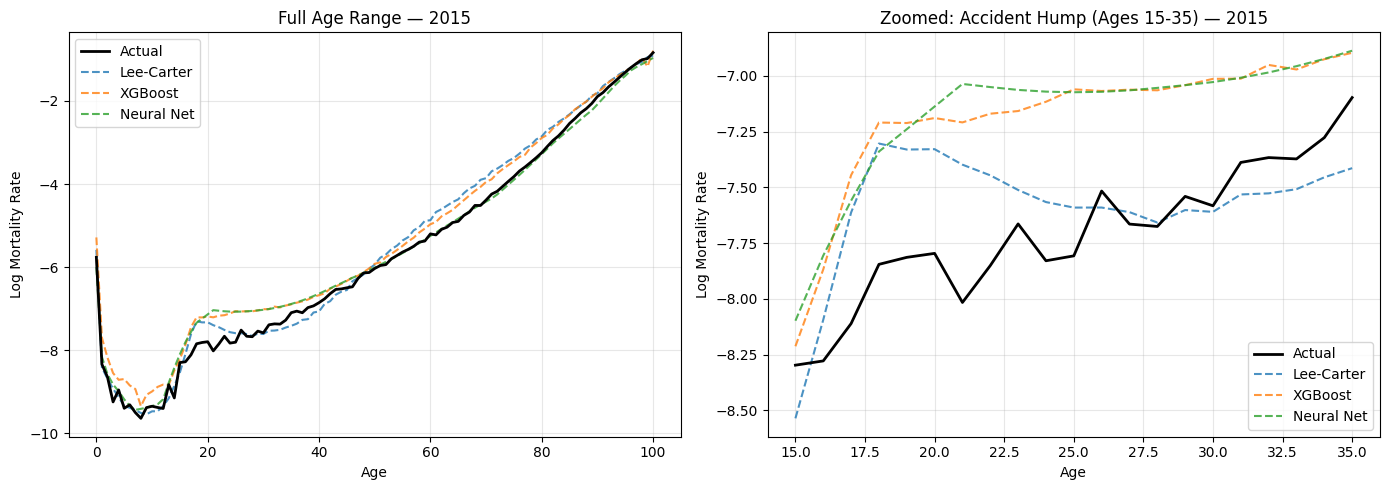

In [24]:
# ── VISUALISATION 3: ZOOMED ACCIDENT HUMP (ages 15-35) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full curve
axes[0].plot(ages_plot, actual_2015, 'k-', linewidth=2, label='Actual', zorder=5)
axes[0].plot(ages_plot, lc_2015, '--', label='Lee-Carter', alpha=0.8)
axes[0].plot(ages_plot, xgb_2015, '--', label='XGBoost', alpha=0.8)
axes[0].plot(ages_plot, nn_2015, '--', label='Neural Net', alpha=0.8)
axes[0].set_title(f'Full Age Range — {yr}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Log Mortality Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# zoomed accident hump
zoom_ages = (ages_plot >= 15) & (ages_plot <= 35)
axes[1].plot(ages_plot[zoom_ages], actual_2015[zoom_ages], 'k-', linewidth=2, label='Actual', zorder=5)
axes[1].plot(ages_plot[zoom_ages], lc_2015[zoom_ages], '--', label='Lee-Carter', alpha=0.8)
axes[1].plot(ages_plot[zoom_ages], xgb_2015[zoom_ages], '--', label='XGBoost', alpha=0.8)
axes[1].plot(ages_plot[zoom_ages], nn_2015[zoom_ages], '--', label='Neural Net', alpha=0.8)
axes[1].set_title(f'Zoomed: Accident Hump (Ages 15-35) — {yr}')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Log Mortality Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

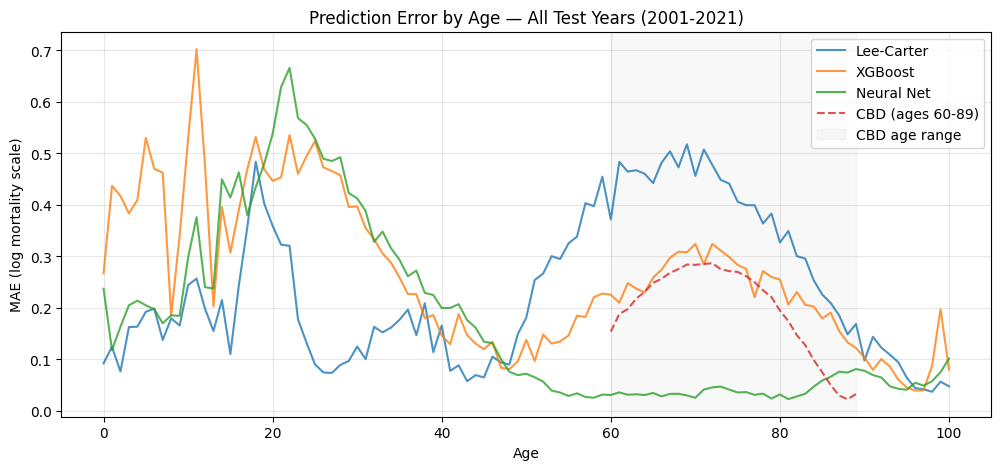

In [25]:
# ── VISUALISATION 4: ERROR BY AGE ────────────────────────────────────────────
test_df = df[df['Year'] > 2000].sort_values(['Age', 'Year'])
test_ages = np.arange(0, 101)

mae_by_age_lc = []
mae_by_age_xgb = []
mae_by_age_nn = []
mae_by_age_cbd = []

for age in test_ages:
    age_data = test_df[test_df['Age'] == age]
    if len(age_data) == 0:
        continue
    
    actual_age = age_data['log_mx_total'].values
    test_yrs_age = age_data['Year'].values
    
    # lee-carter
    lc_preds = []
    for yr in test_yrs_age:
        yr_idx = np.where(test_years == yr)[0][0]
        lc_preds.append(alpha_lc[age] + beta_lc[age] * kappa_fore[yr_idx])
    
    # xgboost
    X_age = np.column_stack([
        np.full(len(test_yrs_age), age),
        test_yrs_age,
        np.full(len(test_yrs_age), np.log1p(age)),
        np.full(len(test_yrs_age), age**2)
    ])
    xgb_preds = model_xgb.predict(X_age)
    
    # neural net
    X_age_scaled = scaler.transform(X_age)
    X_age_t = torch.FloatTensor(X_age_scaled)
    model_nn.eval()
    with torch.no_grad():
        nn_preds = model_nn(X_age_t).numpy()
    
    mae_by_age_lc.append(mean_absolute_error(actual_age, lc_preds))
    mae_by_age_xgb.append(mean_absolute_error(actual_age, xgb_preds))
    mae_by_age_nn.append(mean_absolute_error(actual_age, nn_preds))
    
    # cbd — only available for ages 60-89
    if 60 <= age <= 89:
        cbd_preds = []
        for i, yr in enumerate(test_yrs_age):
            yr_idx = np.where(test_years_cbd == yr)[0][0]
            age_c = age - x_bar
            pred_logit = kappa1_fore[i] + kappa2_fore[i] * age_c
            pred_qx = np.exp(pred_logit) / (1 + np.exp(pred_logit))
            pred_mx = pred_qx / (1 - 0.5 * pred_qx)
            cbd_preds.append(np.log(pred_mx))
        mae_by_age_cbd.append((age, mean_absolute_error(actual_age, cbd_preds)))

# plot
cbd_ages = [x[0] for x in mae_by_age_cbd]
cbd_maes = [x[1] for x in mae_by_age_cbd]

plt.figure(figsize=(12, 5))
plt.plot(test_ages, mae_by_age_lc, label='Lee-Carter', alpha=0.8)
plt.plot(test_ages, mae_by_age_xgb, label='XGBoost', alpha=0.8)
plt.plot(test_ages, mae_by_age_nn, label='Neural Net', alpha=0.8)
plt.plot(cbd_ages, cbd_maes, label='CBD (ages 60-89)', alpha=0.8, linestyle='--')
plt.axvspan(60, 89, alpha=0.05, color='grey', label='CBD age range')
plt.xlabel('Age')
plt.ylabel('MAE (log mortality scale)')
plt.title('Prediction Error by Age — All Test Years (2001-2021)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()